In [16]:
import scanpy as sc
import squidpy as sq
import tangram as tg
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import json
import os

In [2]:
data_dir = os.path.expanduser("../data/151673")
table_dir = os.path.expanduser("../results/tables")
figure_dir = os.path.expanduser("../results/figures") 
ref_dir = os.path.expanduser("../data/snrna_ref")

In [3]:
adata_st = sc.read_h5ad(os.path.expanduser(
    "../data/processed/04_all_clustering.h5ad"))
adata_sc = sc.read_h5ad(os.path.join(ref_dir, "MTG_ref_subsampled.h5ad"))

In [4]:
sc.tl.rank_genes_groups(adata_sc, groupby='subclass_label', method='wilcoxon')
markers = sc.get.rank_genes_groups_df(adata_sc, group=None)

In [5]:
top_markers = markers.groupby('group').head(100)['names'].unique().tolist()
marker_genes = [g for g in top_markers if g in adata_st.var_names]
print(f"Marker genes for training: {len(marker_genes)}")

Marker genes for training: 1279


In [6]:
tg.pp_adatas(adata_sc, adata_st, genes=marker_genes)

INFO:root:1279 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:16197 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [7]:
rna_count = np.array(adata_st.X.sum(axis=1)).squeeze()
adata_st.obs['rna_count_based_density'] = rna_count / rna_count.sum()

In [8]:
ad_map = tg.map_cells_to_space(
    adata_sp=adata_st,
    adata_sc=adata_sc,
    mode='clusters',
    cluster_label='subclass_label',
    density_prior='rna_count_based',
    device='cpu',
    num_epochs=500
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 1279 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.327, KL reg: 0.050
Score: 0.399, KL reg: 0.000
Score: 0.400, KL reg: 0.000
Score: 0.400, KL reg: 0.000
Score: 0.400, KL reg: 0.000


INFO:root:Saving results..


In [9]:
tg.project_cell_annotations(
    ad_map, adata_st, 
    annotation='subclass_label'
)

ct_pred = adata_st.obsm['tangram_ct_pred']

print(adata_st.obsm['tangram_ct_pred'].head())
print(ct_pred.max())
print(ct_pred.head())
print(f"Cell types: {ct_pred.columns.tolist()}")

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


                    Astrocyte  Chandelier       L2/3 IT         L4 IT  \
AAACAAGTATCTCCCA-1   0.000281    0.000009  6.015692e-04  1.980421e-03   
AAACAATCTACTAGCA-1   0.000514    0.000007  1.025047e-05  3.955248e-07   
AAACACCAATAACTGC-1   0.000060    0.000717  3.127979e-07  1.640195e-07   
AAACAGAGCGACTCCT-1   0.000526    0.000080  1.046602e-06  1.395474e-06   
AAACAGCTTTCAGAAG-1   0.000406    0.000015  1.641008e-06  2.219037e-06   

                     L5/6 NP         L5 IT     L6 IT     L6 CT  \
AAACAAGTATCTCCCA-1  0.000006  5.250643e-06  0.000031  0.000109   
AAACAATCTACTAGCA-1  0.000003  4.520666e-07  0.000003  0.000164   
AAACACCAATAACTGC-1  0.000309  3.076245e-07  0.000002  0.000868   
AAACAGAGCGACTCCT-1  0.000568  6.524937e-07  0.000876  0.000005   
AAACAGCTTTCAGAAG-1  0.000953  6.567896e-06  0.000657  0.000012   

                    Oligodendrocyte      Pax6  ...  Microglia-PVM  \
AAACAAGTATCTCCCA-1     3.333868e-07  0.000019  ...       0.000204   
AAACAATCTACTAGCA-1     2.1

In [14]:
ct_by_layer = ct_pred.copy()
ct_by_layer['ground_truth'] = adata_st.obs['ground_truth'].values
layer_mean = ct_by_layer.groupby('ground_truth').mean()
print(layer_mean.round(6))

              Astrocyte  Chandelier   L2/3 IT     L4 IT   L5/6 NP     L5 IT  \
ground_truth                                                                  
Layer1         0.000339    0.000193  0.000247  0.000116  0.000125  0.000052   
Layer2         0.000317    0.000283  0.001021  0.000110  0.000179  0.000033   
Layer3         0.000263    0.000338  0.000628  0.000425  0.000245  0.000171   
Layer4         0.000233    0.000375  0.000099  0.000841  0.000341  0.000363   
Layer5         0.000262    0.000307  0.000024  0.000346  0.000504  0.000936   
Layer6         0.000297    0.000208  0.000023  0.000128  0.000254  0.000112   
WM             0.000268    0.000218  0.000004  0.000034  0.000177  0.000047   

                 L6 IT     L6 CT  Oligodendrocyte      Pax6  ...  \
ground_truth                                                 ...   
Layer1        0.000173  0.000154         0.000021  0.000346  ...   
Layer2        0.000334  0.000216         0.000008  0.000402  ...   
Layer3        0.

In [11]:
key_celltypes = [['Oligodendrocyte', 'L2/3 IT', 'L5 ET', 'Astrocyte']]
print(ct_pred.columns.tolist())

['Astrocyte', 'Chandelier', 'L2/3 IT', 'L4 IT', 'L5/6 NP', 'L5 IT', 'L6 IT', 'L6 CT', 'Oligodendrocyte', 'Pax6', 'L6 IT Car3', 'L6b', 'Lamp5', 'Lamp5 Lhx6', 'Microglia-PVM', 'OPC', 'Sst', 'Vip', 'Pvalb', 'Sncg', 'L5 ET', 'Sst Chodl', 'VLMC', 'Endothelial']


In [12]:
for ct in ct_pred.columns:
    adata_st.obs[f'tangram_{ct}'] = ct_pred[ct].values

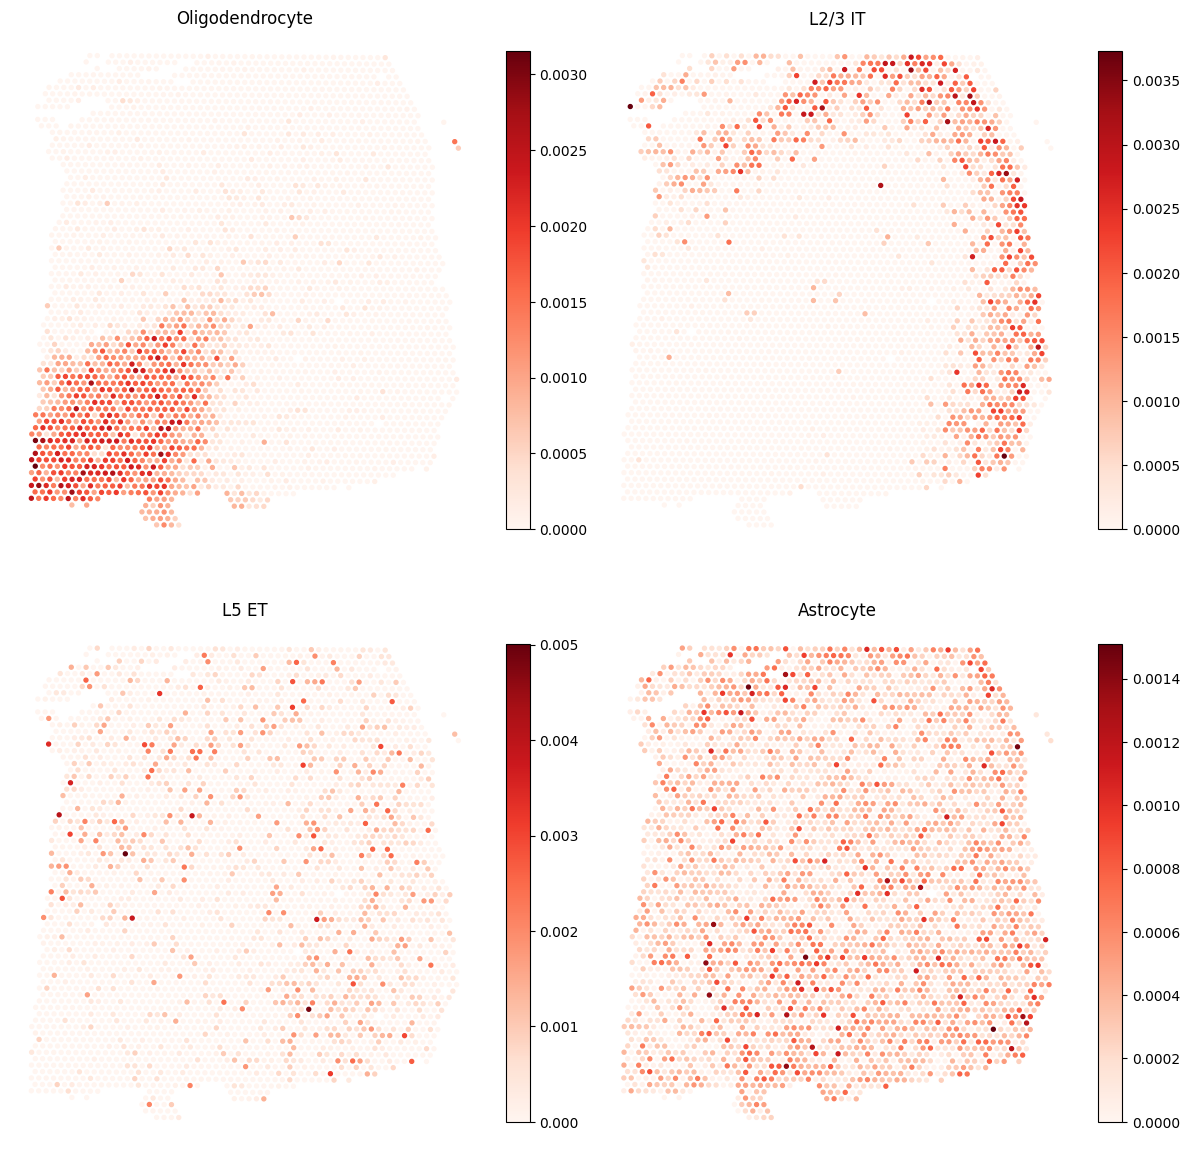

In [15]:
ct_norm = ct_pred.div(ct_pred.max(axis=0), axis=1)
key_celltypes = ['Oligodendrocyte', 'L2/3 IT', 'L5 ET', 'Astrocyte']

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
coords = adata_st.obsm['spatial']

for ax, ct in zip(axes.flat, key_celltypes):
    sc_plot = ax.scatter(coords[:, 0], coords[:, 1],
                        c=adata_st.obs[f'tangram_{ct}'], cmap='Reds', s=8, vmin=0)
    ax.set_title(ct)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    plt.colorbar(sc_plot, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("../results/figures/tangram_deconvolution.png", dpi=200, bbox_inches='tight')
plt.show()

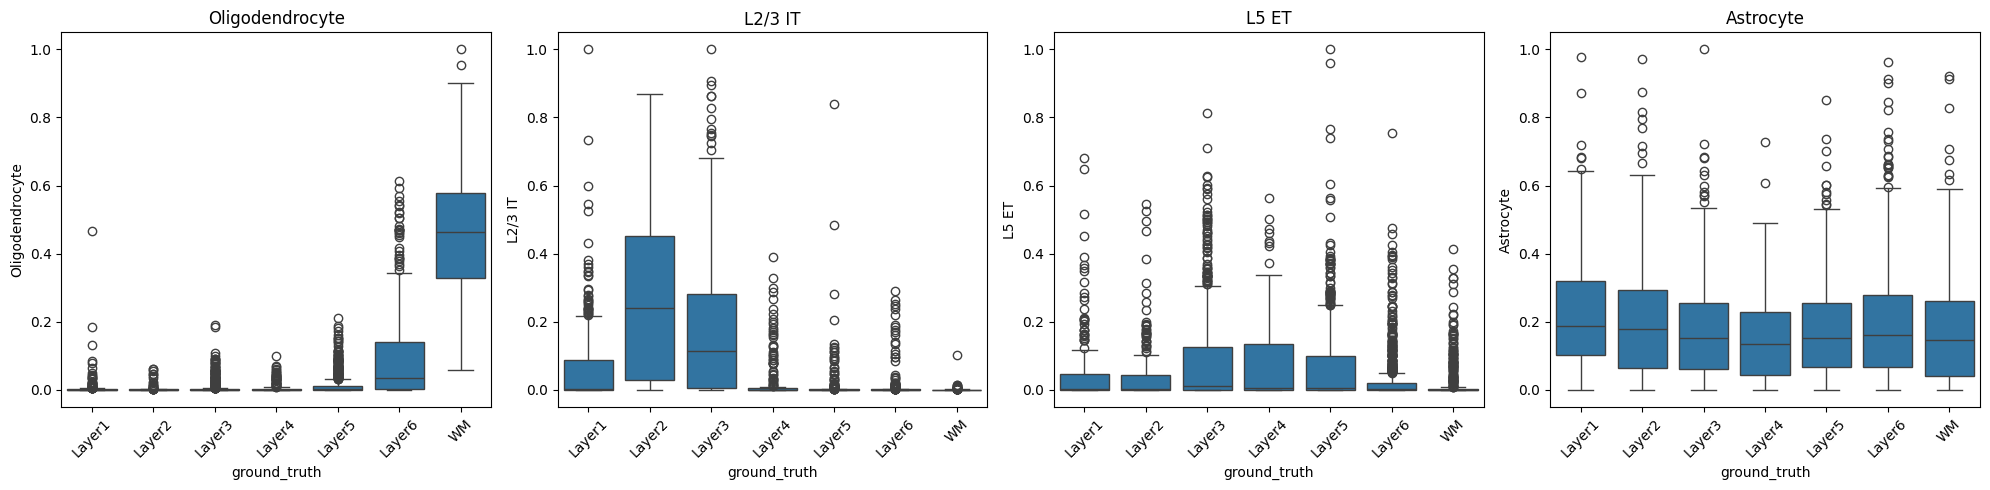

In [17]:
ct_norm = ct_pred.div(ct_pred.max(axis=0), axis=1)
ct_with_gt = ct_norm.copy()
ct_with_gt["ground_truth"] = adata_st.obs["ground_truth"].values

key_cts = ["Oligodendrocyte", "L2/3 IT", "L5 ET", "Astrocyte"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, ct in enumerate(key_cts):
    data = ct_with_gt[ct_with_gt["ground_truth"].notna()]
    sns.boxplot(data=data, x="ground_truth", y=ct, ax=axes[i],
                order=["Layer1","Layer2","Layer3","Layer4","Layer5","Layer6","WM"])
    axes[i].set_title(ct)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "tangram_ct_by_layer_boxplot.png"),
            dpi=200, bbox_inches='tight')
plt.show()

In [18]:
adata_st.write(os.path.join("../data/processed/05_deconvolved.h5ad"))